In [72]:
%load_ext autoreload
%autoreload 2

import sys
import os

chemin_racine = os.path.abspath('..')

if chemin_racine not in sys.path:
    sys.path.append(chemin_racine)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Analyse Exploratoire des Données

__Objectif Métier :__ Analyser le profil financier des emprunteurs afin de préparer les données pour un modèle de Credit Scoring (Prédiction de la Probabilité de Défaut).

__Jeu de données :__ [Give Me Some Credit de Kaggle](https://www.kaggle.com/competitions/GiveMeSomeCredit/data)

Ici, il s'agit essentiellement d'une première prise en main des données, puis du nettoyage de celles-ci (traitement des données aberrantes, manquantes...), nous pourrons ensuite observer leur distribution avant de passer au Feature engineering.

## a. Imports et premières observations
Dans un premier temps, on importe les bibliothèques utiles et le jeu de données et on assigne nos données à des variables.

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.core.pylabtools import figsize

description_donnees = pd.read_excel("../data/raw/Data Dictionary.xls", index_col=1)
description_donnees

,Unnamed: 0,Unnamed: 2
Description,Variable Name,Type
Person experienced 90 days past due delinquency or worse,SeriousDlqin2yrs,Y/N
Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits,RevolvingUtilizationOfUnsecuredLines,percentage
Age of borrower in years,age,integer
Number of times borrower has been 30-59 days past due but no worse in the last 2 years.,NumberOfTime30-59DaysPastDueNotWorse,integer
"Monthly debt payments, alimony,living costs divided by monthy gross income",DebtRatio,percentage
Monthly income,MonthlyIncome,real
Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards),NumberOfOpenCreditLinesAndLoans,integer
Number of times borrower has been 90 days or more past due.,NumberOfTimes90DaysLate,integer
Number of mortgage and real estate loans including home equity lines of credit,NumberRealEstateLoansOrLines,integer


On comprend que la variable cible, que l'on cherche à prédire, de notre étudie sera la variabe ```SeriousDlqin2yrs``` puisqu'on voit dans sa description "Person experienced 90 days past due delinquency or worse" ce qui correspond justement à la réponse de la question à laquelle on cherche à répondre : "Si je prête de l'argent à cette personne aujourd'hui, a-t-elle de fortes chances de cesser de me rembourser dans les 24 prochains mois ?"

In [74]:
train_credit_data = pd.read_csv("../data/raw/cs-training.csv", index_col=0, header=0)
train_credit_data.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [75]:
test_credit_data = pd.read_csv("../data/raw/cs-test.csv", index_col=0, header=0)
test_credit_data.head() # Le fait que SeriousDlqin2yrs	soit en NaN dans la data de test confirme la conclusion précédente

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,NaN,0.885519,43,0,0.177513,5700.0,4,0,0,0,0.0
2,NaN,0.463295,57,0,0.527237,9141.0,15,0,4,0,2.0
3,NaN,0.043275,59,0,0.687648,5083.0,12,0,1,0,2.0
4,NaN,0.280308,38,1,0.925961,3200.0,7,0,2,0,0.0
5,NaN,1.000000,27,0,0.019917,3865.0,4,0,0,0,1.0


## b. Traitement des Données Manquantes
La prochaine étape de notre étude va être de déterminer les variables qui comportent des données manquantes, on va ensuite discuter des hypothèses potentielles de ces manques et de comment nous allons les traiter.

In [76]:
train_credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

In [77]:
compteur_nan = train_credit_data.isna().mean()
print(compteur_nan.sort_values(ascending=False)*100)


MonthlyIncome                           19.820667
NumberOfDependents                       2.616000
SeriousDlqin2yrs                         0.000000
age                                      0.000000
RevolvingUtilizationOfUnsecuredLines     0.000000
DebtRatio                                0.000000
NumberOfTime30-59DaysPastDueNotWorse     0.000000
NumberOfOpenCreditLinesAndLoans          0.000000
NumberOfTimes90DaysLate                  0.000000
NumberRealEstateLoansOrLines             0.000000
NumberOfTime60-89DaysPastDueNotWorse     0.000000
dtype: float64


On tire plusieurs informations de notre appel à la méthode info() :
- On a un total de 150000 profils clients dans les données d'entraînement
- Parmi les variables, ```MonthlyIncome``` et ```NumberOfDependents``` sont celles qui présentent des données manquantes
    - Pour ```MonthlyIncome``` : On a 19.82% de valeurs manquantes
    - Pour ```NumberOfDependents``` : on a 2.61% de valeurs manquantes

 ## i. Variable : ```MonthlyIncome```
   - __Hypothèse :__ Ici, on peut deviner plusieurs raisons potentielles qui auraient poussé un client à laisser cette case vide :
       - Complexité : Le revenu du client est complexe et ne se résume pas en un monthly income
       - Précarité : c'est un revenu faible, le client ayant peur que cette statistique lui fasse défaut, il la cache
       - Irrégularité : son revenu mensuel est très volatile et le client ne sait pas quoi mettre
   - __Nature Statistique :__ Puisqu'on a pu identifier de nombreuses raisons potentielels d'omission volontaire, on conjecture que cette variable est de type MNAR (Missing not at random)
   - __Stratégie de traitement et validation :__ On va choisir d'utiliser une méthode d'imputation couplée à un indicateur binaire, ainsi, on peut à la fois combler le manque pour notre régression logistique et prendre en compte l'origine comportementale du trou. La distribution des revenus étant fortement étalée vers la droite, choisit la médiane comme stratégie étant donné la sensibilité de la moyenne aux valeurs extrêmes.

 ## ii. Variable : ```NumberOfDependents```
 - __Hypothèse :__ Cette variable indique le nombre de personnes à charge. On suppose qu'ici, une missing value peut être due au fait que le client suppose que laisser la case vide lors du remplissage est un 0 explicite.
 - __Nature Statistique :__ Ici aussi, on a probablement un cas de MNAR.
 - __Stratégie de traitement et validation :__ Si l'hypothèse est avérée, on va faire le choix de remplacer les NaN par des 0. Pour valider l'hypothèse, on va essayer de voir si $$\mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=\text{NaN}) \approx \mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=0)$$


### Validation de l'hypothèse pour ```NumberOfDependents```
On pose $P_1 = \mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=\text{NaN})$ et $P_2 =\mathbb{P}(\text{SeriousDlqin2yrs}=1 \mid \text{NumberOfDependents}=0)$

In [78]:
masque = train_credit_data["NumberOfDependents"].isna()
train_data_nod_na = train_credit_data.loc[masque]

p_1 = train_data_nod_na["SeriousDlqin2yrs"].mean()

train_data_nod_0 = train_credit_data.loc[train_credit_data["NumberOfDependents"] == 0]
p_2 = train_data_nod_0["SeriousDlqin2yrs"].mean()

print(f'P_1 = {p_1}\nP_2 = {p_2}\n|P_1 - P_2| = {abs(p_1-p_2)*100}')


P_1 = 0.04561671763506626
P_2 = 0.05862926054636257
|P_1 - P_2| = 1.3012542911296312


On trouve au final que $| P_1 - P_2 | \approx 1.3 \%$, on a donc un écart assez faible pour valider notre conjecture initiale pour cette variable, on va donc appliquer la stratégie de traitement qui va être de remplacer les NaN par des 0.

In [79]:
train_credit_data["NumberOfDependents"] = train_credit_data["NumberOfDependents"].fillna(0)
train_credit_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
dtypes: float64(

### Mise en place de la stratégie d'imputation pour ```MonthlyIncome```
On fait le choix d'utiliser l'outil ```SimpleImputer``` de scikit learn. On fixe ```strategy = 'median'``` et ```add_indicator = True```.

In [80]:
from sklearn.impute import SimpleImputer

imputer_income = SimpleImputer(strategy="median",add_indicator=True)
new_income = imputer_income.fit_transform(train_credit_data[["MonthlyIncome"]])

train_credit_data["MonthlyIncome"] = new_income[:,0]
train_credit_data["MissingIncomeFlag"] = new_income[:,1]

train_credit_data.info() #Plus aucune missing value
train_credit_data["MonthlyIncome"].describe()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 1 to 150000
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         150000 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    150000 non-null  float64
 11  MissingInco

count    1.500000e+05
mean     6.418455e+03
std      1.289040e+04
min      0.000000e+00
25%      3.903000e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

On conclut qu'il n'y a plus aucune valeur manquante dans notre dataset, on peut donc passer au traitement des valeurs extrêmes.

## c. Traitement des données manquantes
Ici, le but va être de repérer les valeurs aberrantes dans le jeu de données puis d'en analyser les causes possibles. Selon les conclusions, nous choisirons une méthode adaptée pour les lisser

In [81]:
train_credit_data.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MissingIncomeFlag
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.500000e+05,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.418455e+03,8.452760,0.265973,1.018240,0.240387,0.737413,0.198207
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.289040e+04,5.145951,4.169304,1.129771,4.155179,1.107021,0.398650
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.903000e+03,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,7.400000e+03,11.000000,0.000000,2.000000,0.000000,1.000000,0.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000,1.000000


In [82]:
cols_anomalie = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "age"
]

for col in cols_anomalie:
    print(train_credit_data[col].value_counts().sort_index())

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64
NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64
NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64
age
0        1
21     183
22     434
23     641
24     816
      ... 
102      3
103      3
105      1
107      1
109      2
Name: count, Length: 86, dtype: int64


L'appel à la méthode .describe() montre trois anomalies dans la distribution de nos variables et qui ont donc besoin d'un traitement spécifique :

1. Variable `age` :
    - __Observation :__ L'âge minimum relevé dans la base est de 0 an. Après un unique count on remarque que c'est un unique cas isolé et que le reste des âges commence à 21, sûrement l'âge légal pour contracter un crédit aux Etats Unis
    - __Analyse :__ C'est évidemment impossible autant biologiquement que légalement. C'est sûrement une erreur de frappe ou d'une valeur de remplacement par défaut d'un ancien système (pour éviter les NaN par ex).
    - __Décision :__ On va remplacer la ligne par la médiane pour ne pas en perdre l'information.


2. Variable ``MonthlyIncome``
    - __Observation :__ La valeur maximale atteint 3 000 000, ce qui est totalement déconnecté du 3ème quartile (75 %) qui reste dans des chiffres raisonnables (7400 environs).
    - __Analyse :__ Cette valeur peut correspondre soit à un profil très riche (risque très faible), soit à une erreur de remplissage où le client a mis son revenu ou son patrimoine annuel au lieu de son revenu mensuel.
    - __Décision :__ On va faire le choix de plafonner cette variable pour éviter de biaiser notre régression.


3. Variables de retards de paiement (```NumberOfTime...```)
    - __Observation :__ Les variables mesurant le nombre de fois où un client a été en retard (30-59Days, 60-89Days, 90DaysLate) ont des maximums aberrants systématiquement plafonnés à 98, très éloignés du 75ème centile. Après un affichage des unique counts de chacune de ces variables, on observe que les deux valeurs aberrantes qui reviennent systématiquement sont 98 et 96.
    - __Analyse :__ Mathématiquement et financièrement, accumuler 98 fois un retard de 90 jours est impossible (la banque aurait saisi les biens bien avant). Après recherche, en particulier dans les forums de Kaggle (notamment dans [cette discussion](https://www.kaggle.com/competitions/GiveMeSomeCredit/discussion/867)), de nombreux utilisateurs ont relevé ces valeurs. Le consensus est qu'il s'agit de codes internes aux sources de ces données, ce ne sont donc pas des valeurs numériques à prendre dans leur sens littéral mais plutôt des valeurs qui ont des "sens cachés". Une observation intéressante est que le nombre de 98 est systématiquement identique pour chacun des intervalles de retard (exactement 264), pareil pour 96 (exactement 5).
    - __Décision :__ Une des méthodes les plus précises serait de faire un modèle dédié au profiling des personnes qui ont ce 98 (ou 96), mais c'est trop complexe pour cette étape. On va donc évaluer leur proportion dans le dataset pour déterminer la méthode la plus adaptée (les exclure ou les écraser).

### Traîtement de l'âge :

C'est une valeur unique, on va simplement la remplacer par la médiane des âges.

In [83]:
age_median = train_credit_data["age"].median()
train_credit_data.loc[train_credit_data["age"]== 0, "age"] = age_median
train_credit_data["age"].value_counts().sort_index()

age
21     183
22     434
23     641
24     816
25     953
      ... 
102      3
103      3
105      1
107      1
109      2
Name: count, Length: 85, dtype: int64

### Traitement des extrêmes en `MonthlyIncome`

Pour éviter que les valeurs extrêmes de cette variable ne biaisent trop nos modèles, en particulier la régression logistique, on fait le choix de les capper à un centile inférieur, que l'on va déterminer en cherchant le point d'inflexion de l'écart entre les quantiles supérieurs.

In [84]:
from src.utils import etude_sauts_quantiles, cap_outliers_quantile

print(etude_sauts_quantiles(train_credit_data, "MonthlyIncome"))

          quantile         diff
0.900    10750.000          NaN
0.910    11105.180      355.180
0.920    11666.000      560.820
0.930    12120.000      454.000
0.940    12744.180      624.180
0.950    13500.000      755.820
0.960    14600.000     1100.000
0.970    16000.000     1400.000
0.980    18000.000     2000.000
0.990    23000.000     5000.000
0.995    31250.000     8250.000
0.996    35000.000     3750.000
0.997    40000.000     5000.000
0.998    50440.120    10440.120
0.999    72759.157    22319.037
1.000  3008750.000  2935990.843


On observe que le point d'inflexion se situe entre le quantile 0.999 et le maximum absolu. On fait donc le choix de capper les valeurs extrêmes à la valeur du quantile 0.999 qui est de ``72760`` environs, ce qui reste une valeur plausible contrairement à l'extrême qui donne un saut de presque 3 millions. Un tel salaire mensuel parait peu probable, on peut imaginer que c'est une erreur de saisie (salaire annuel, patrimoine total...).

In [85]:
train_credit_data = cap_outliers_quantile(train_credit_data, "MonthlyIncome", 0.999)
train_credit_data["MonthlyIncome"].describe()


MonthlyIncome : Plafonné au quantile 0.999 (Valeur max = 72759.16)


count    150000.000000
mean       6293.293817
std        4957.897322
min           0.000000
25%        3903.000000
50%        5400.000000
75%        7400.000000
max       72759.157000
Name: MonthlyIncome, dtype: float64

Avec cette modification, on observe que l'écart type pour cette variable passe de 12890 à 4958, on voit donc bien que cette minorité de valeurs extrêmes avait une influence importante sur la dispersion des données, ce qui aurait pu fortement biaiser toute régression.

### Traîtement des variables de retard de paiement

Précédemment, on a vu que pour les trois variables `NumberOfTime30-59DaysPastDueNotWorse, NumberOfTime60-89DaysPastDueNotWorse` et `NumberOfTimes90DaysLate`, il y avait exactement 264 clients à 98 et 5 à 96. On cherche d'abord à savoir si ce sont les mêmes personnes ou si l'intersection entre ces groupes est vide.

In [86]:
retard = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTime60-89DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate"
    ]
masque_code = train_credit_data["NumberOfTimes90DaysLate"].isin([98,96])
retards_90 = train_credit_data.loc[masque_code]
retards_90[retard].value_counts().sort_index()



NumberOfTime30-59DaysPastDueNotWorse  NumberOfTime60-89DaysPastDueNotWorse  NumberOfTimes90DaysLate
96                                    96                                    96                           5
98                                    98                                    98                         264
Name: count, dtype: int64

On conclut que ce sont les mêmes 269 profils clients qui affichent les codes 96 et 98 pour les trois variables. Ce nombre étant marginal (environs 0.2% de l'échantillon), on fait le choix de supprimer les clients affectés.

In [87]:
train_credit_data = train_credit_data.loc[~masque_code]
train_credit_data.shape

(149731, 12)

On a correctement supprimé les anomalies, le dataset est réduit à 149 731 lignes au lieu de 150 000

## d. Analyse bivariée conditionnelle
Ici, nous allons observer le comportement des variables explicatives en fonction de la variable cible (`SeriousDlqin2yrs`) en utilisant la bibliothèque `seaborn`.

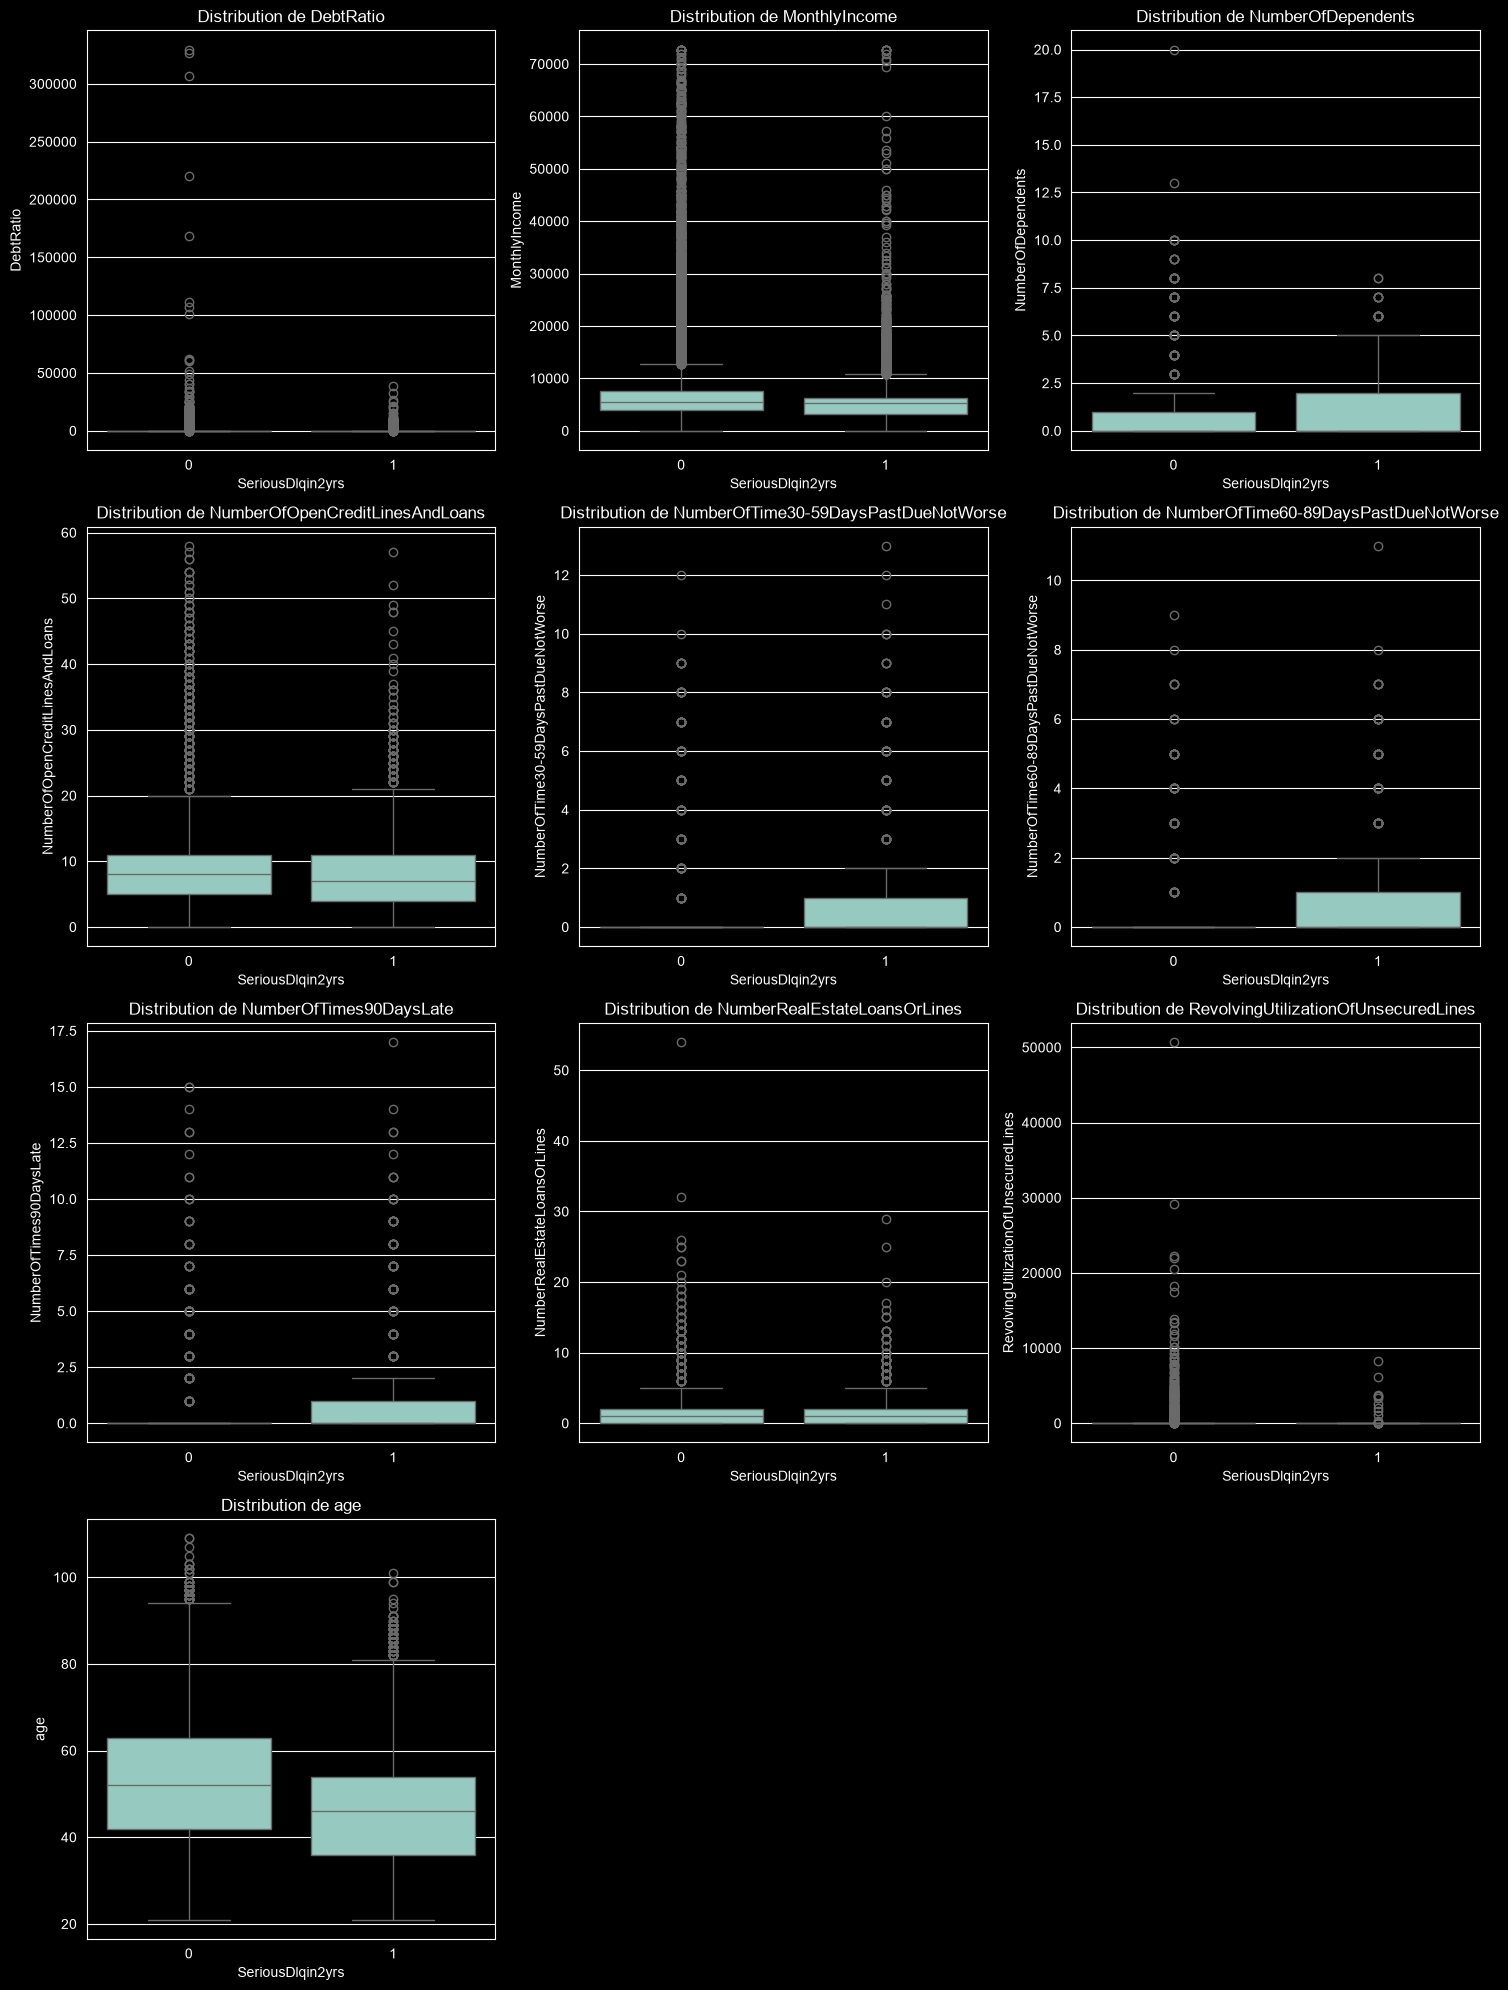

In [88]:
import seaborn as sns
import math
NCOLS = 3

tags_var_etude = train_credit_data.columns.difference(["SeriousDlqin2yrs", "MissingIncomeFlag"])
y_etude = train_credit_data["SeriousDlqin2yrs"]

nrows = math.ceil(len(tags_var_etude)/NCOLS)
fig, axes = plt.subplots(nrows=nrows, ncols=NCOLS, figsize=(15, 5 * nrows))
axes_flat = axes.flatten()

for i, col in enumerate(tags_var_etude):
    sns.boxplot(x=y_etude, y=col, data=train_credit_data, ax=axes_flat[i])
    axes_flat[i].set_title(f'Distribution de {col}')

for j in range(len(tags_var_etude),len(axes_flat)):
    axes_flat[j].set_axis_off()

plt.tight_layout()
plt.show()

### Traitement de ``RevolvingUtilizationOfUnsecuredLines``

On constate de nombreuses anomalies pour la variable `RevolvingUtilizationOfUnsecuredLines` (ratios à + de 10000), on commence donc par étudier ce cas et le traiter de manière similaire au traitement fait précédemment pour la variable `MonthlyIncome`.

In [89]:
print(etude_sauts_quantiles(train_credit_data,"RevolvingUtilizationOfUnsecuredLines"))

           quantile          diff
0.900      0.977995           NaN
0.910      0.998668      0.020673
0.920      1.000000      0.001332
0.930      1.000000      0.000000
0.940      1.000000      0.000000
0.950      1.000000      0.000000
0.960      1.000000      0.000000
0.970      1.000000      0.000000
0.980      1.006274      0.006274
0.990      1.093342      0.087068
0.995      1.368207      0.274865
0.996      1.500845      0.132638
0.997      1.762156      0.261311
0.998      2.775223      1.013066
0.999   1572.620000   1569.844777
1.000  50708.000000  49135.380000


On voit très clairement que le saut se fait dès le quantile 0.999, on applique donc le clip ici.

RevolvingUtilizationOfUnsecuredLines : Plafonné au quantile 0.998 (Valeur max = 2.78)


<Axes: xlabel='SeriousDlqin2yrs', ylabel='RevolvingUtilizationOfUnsecuredLines'>

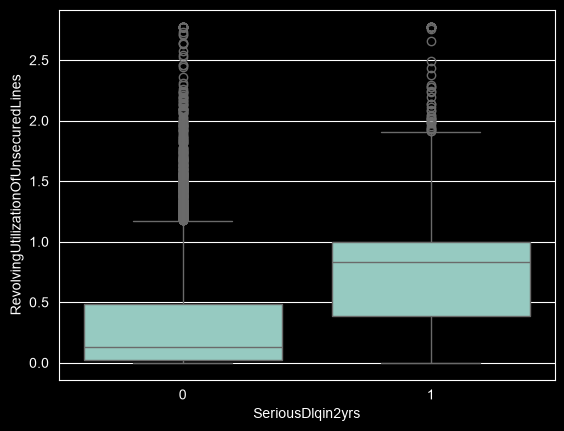

In [90]:
train_credit_data = cap_outliers_quantile(train_credit_data, "RevolvingUtilizationOfUnsecuredLines", 0.998)

sns.boxplot(x=y_etude, y="RevolvingUtilizationOfUnsecuredLines", data=train_credit_data)

On observe un résultat plus sain et cohérent avec la réalité financière avec une distinction claire entre le comportement des bons payeurs et des mauvais payeurs, avec des médianes respectivement à environs 0.15 et 0.85.

### Traitement de la variable `DebtRatio`

Pour cette variable-ci qui est censé représenter un ratio entre dettes mensuelles et revenus mensuels, on observe des valeurs aberrantes, certaines allant jusqu'à 300 000. Notre hypothèse initiale est que ces valeurs extrêmes proviennent de plusieurs sources :
- L'erreur de saisie : Comme toute valeur aberrante, on peut imaginer que l'utilisateur s'est trompé lors de la compréhension de ce qui était nécessaire à saisir pour cette variable
- Les revenus manquants : On peut imaginer que pour les profils où les revenus mensuels étaient manquants (NaN), puisqu'il n'est pas possible de diviser par 0, on a simplement pris la valeur brute de la dette plutôt qu'un ratio
- Les valeurs entières : Une combinaison des deux sources précédentes seraient que l'utilisateur aie saisi le montant chiffré de sa dette plutôt qu'un ratio

Notre premier traitement consistera donc, pour tous les profils flag comme ayant un monthly income manquant, de recalculer le ratio en prenant la valeur initialement soumise dans `DebtRatio` puis de la diviser par la valeur médiane que l'on avait attribuée. Selon l'effet de cet ajustement, on décidera, ou non, de procéder à d'autres traitements sur cette variable.

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

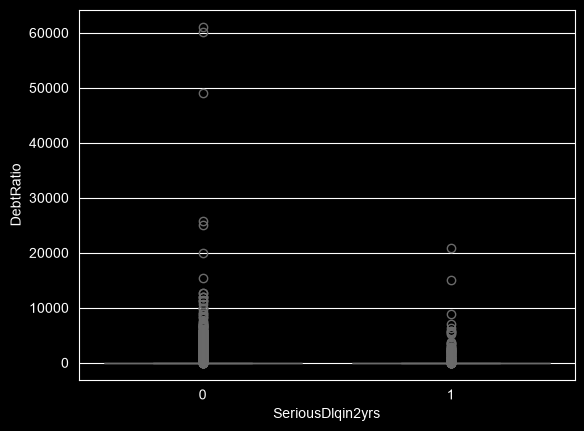

In [91]:
masque = train_credit_data["MissingIncomeFlag"] == 1
train_credit_data.loc[masque,"DebtRatio"] = train_credit_data.loc[masque,"DebtRatio"]/train_credit_data.loc[masque,"MonthlyIncome"]

train_credit_data.loc[masque,"DebtRatio"].describe()
sns.boxplot(x=y_etude, y="DebtRatio", data=train_credit_data)


Même si un certain nombre d'outliers persiste, il y a clairement une nette différence suite à cette opération. On a également vérifié que les outliers restants ne provenaient plus des clients flaggés comme ayant un revenu manquant, on décide donc de traiter le reste de ces valeurs par un clip au point d'inflexion des quantiles.

In [92]:
print(etude_sauts_quantiles(train_credit_data,"DebtRatio"))
train_credit_data = cap_outliers_quantile(train_credit_data, "DebtRatio", 0.980)

           quantile          diff
0.900      0.749630           NaN
0.910      0.787785      0.038156
0.920      0.835456      0.047671
0.930      0.892749      0.057292
0.940      0.961058      0.068310
0.950      1.061494      0.100436
0.960      1.221289      0.159795
0.970      1.492279      0.270990
0.980      2.488060      0.995781
0.990    268.100000    265.611940
0.995   1443.000000   1174.900000
0.996   1783.960000    340.960000
0.997   2185.430000    401.470000
0.998   2778.620000    593.190000
0.999   3926.370000   1147.750000
1.000  61106.500000  57180.130000
DebtRatio : Plafonné au quantile 0.98 (Valeur max = 2.49)


On décide ici de faire un clipping strict puisque dès le quantile 0.990, des valeurs aberrantes comme 268 soit 26800% de ratio de dette commencent à apparaître. Ce sont des ratios de dette aberrants et les laisser dans le jeu de données biaiserait beaucoup trop les modèles.

<Axes: xlabel='SeriousDlqin2yrs', ylabel='DebtRatio'>

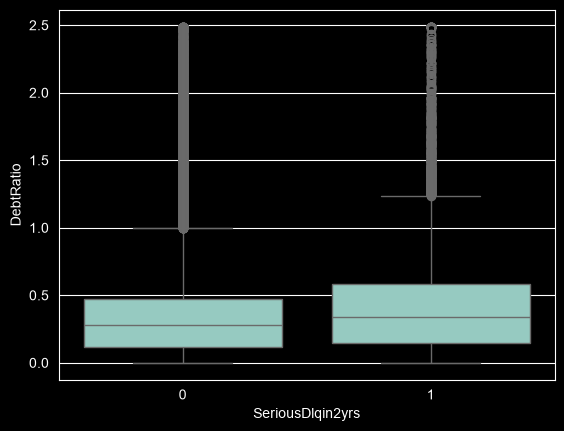

In [93]:
sns.boxplot(x=y_etude, y="DebtRatio", data=train_credit_data)

Le boxplot résultant montre une donnée saine en cohérence avec la réalité du monde financier. Pour les bons payeurs, on a une médiane à environs 25%, celle des mauvais payeurs est plus haute vers 45%. De pus, on voit une nette différence entre les Q3 des deux groupes avec l'un à 100% et l'autre à prs de 120%

## e. Déséquilibre de la classe `SeriousDlqin2yrs`

Ici, le but va être de quantifier le ratio bons payeurs / mauvais payeurs pour pouvoir faire des choix en fonction de ce ratio dans la suite de la structuration de nos modèles, notamment le choix des métriques de performance.

In [101]:
counts_serious_dlq = train_credit_data["SeriousDlqin2yrs"].value_counts(normalize=True)
ratio_serious_dlq =  float(counts_serious_dlq[0]/counts_serious_dlq[1])
print(counts_serious_dlq, '\n', ratio_serious_dlq)


SeriousDlqin2yrs
0    0.934022
1    0.065978
Name: proportion, dtype: float64 
 14.156493572223908


On a donc un ratio d'environs 14 bons payeurs pour 1 mauvais payeur, c'est une statistique que l'on utilisera pour nos modèles de ML pour éviter de tomber dans des pièges de fausses performances.